# MNIST MLP - 가장 단순한 시작

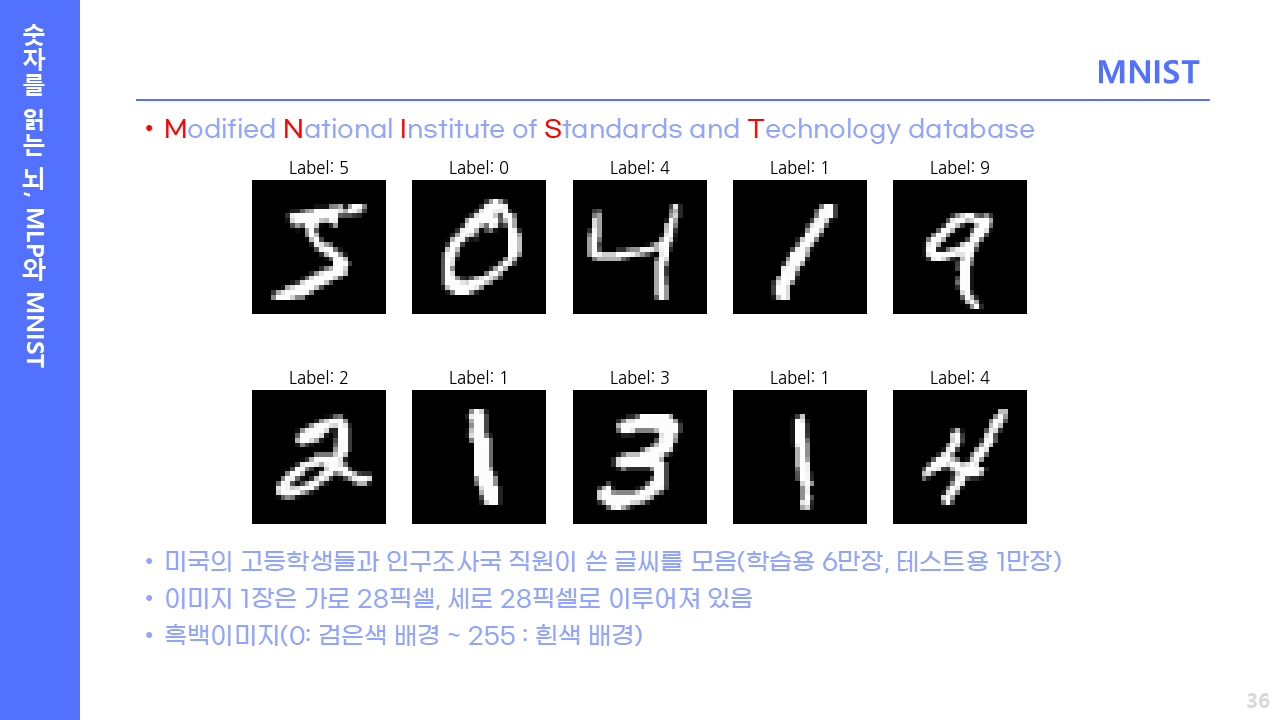

# 1. 모듈 불러오기

- requirements.txt 파일을 생성하기
```shell
tensorflow
koreanize_matplotlib
```


- cmd에서 pip install -r requirements.txt 실행
- **사전에 모든 라이브러리 설치 완료!!**

In [1]:
# 각종 모듈 불러오기

import os, random
import numpy as np
import tensorflow as tf
import koreanize_matplotlib
import matplotlib.pyplot as plt

I0000 00:00:1786537371.025380    4693 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


- 각 모듈의 역할
>- `os, random` : 다음 셀에서 랜덤 시드 고정할 때 사용. `os`는 환경변수 조작, `random`은 파이썬 기본 난수 생성기
>- `numpy` : 수치 계산용. MNIST 이미지는 결국 (28, 28) 행렬이라 NumPy 배열로 다뤄짐
>- `tensorflow` : 딥러닝 프레임워크. 모델 정의, 학습, 평가 전부 여기서 처리
>- `koreanize_matplotlib` : import만 해도 matplotlib의 한글 폰트 깨짐을 자동으로 처리
>- `matplotlib.pyplot` : 학습 결과 그래프(정확도, 손실) 그리기용

# 2. 랜덤시드 고정으로 재연성 확보하기

In [2]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

- 신경망은 가중치가 랜덤으로 초기화됨. 따라서 같은 코드를 돌려도 매번 결과가 미세하게 달라짐
- 시드를 고정하면 누구든 같은 결과가 나옴
>- `PYTHONHASHSEED` : 파이썬 내부 해시 연산
>- `random` : 파이썬 기본 난수
>- `np.random` : NumPy 난수(데이터 셔플 등)
>- `tf.random` : TensorFlow 난수(가중치 초기화, dropout 등)
- 한 군데라도 빼면 그 부분에서 무작위성이 새어 나옴

# 3. 데이터 불러오기

In [3]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


- TensorFlow에 MNIST 데이터가 내장되어 있어 한 줄로 다운로드됨.
- 첫 실행시 인터넷이 필요, 두번째부터는 캐시
- 반환 구조는 튜플 안에 튜플:
>- `x_train` : 학습용 이미지 6만 장, 모양 (60000, 28, 28), 값 0 ~ 255
>- `y_train` : 학습용 정답 6만 개, 모양 (60000,), 값 0 ~ 9
>- `x_test, y_test` : 테스트용 1만 장과 정답
- `y`는 원-핫 인코딩 결과가 아닌 그냥 정수(예: 7). 나중에 손실함수 선택시 `sparse_categorical_crossentropy`를 사용해야 함

# 4. 데이터 정규화 하기

In [4]:
x_train, x_test = x_train / 255.0, x_test / 255.0

- 픽셀의 값을 0 ~ 255 -> 0 ~ 1 범위로 줄임
- 왜?
>- 큰 값이 들어가면 학습이 불안정: ReLU, softmax 같은 활성화 함수가 큰 입력에서 기울기가 폭주하거나 사라짐
>- 경사하강법이 잘 수렴: 값이 너무 크면 한 걸음이 너무 커져서 골짜기를 지나쳐버림
>- 가중치 업데이트가 균형 있게: 모든 입력이 비슷한 스케일이면 가중치가 한쪽으로 쏠리지 않음

# 5-1. MLP 모델 설계

In [5]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

I0000 00:00:1786537527.802916    4693 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79191 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:a0:1c.0, compute capability: 8.0


- `squential`: 층을 순서대로 쌓는 가장 단순한 모델 구조

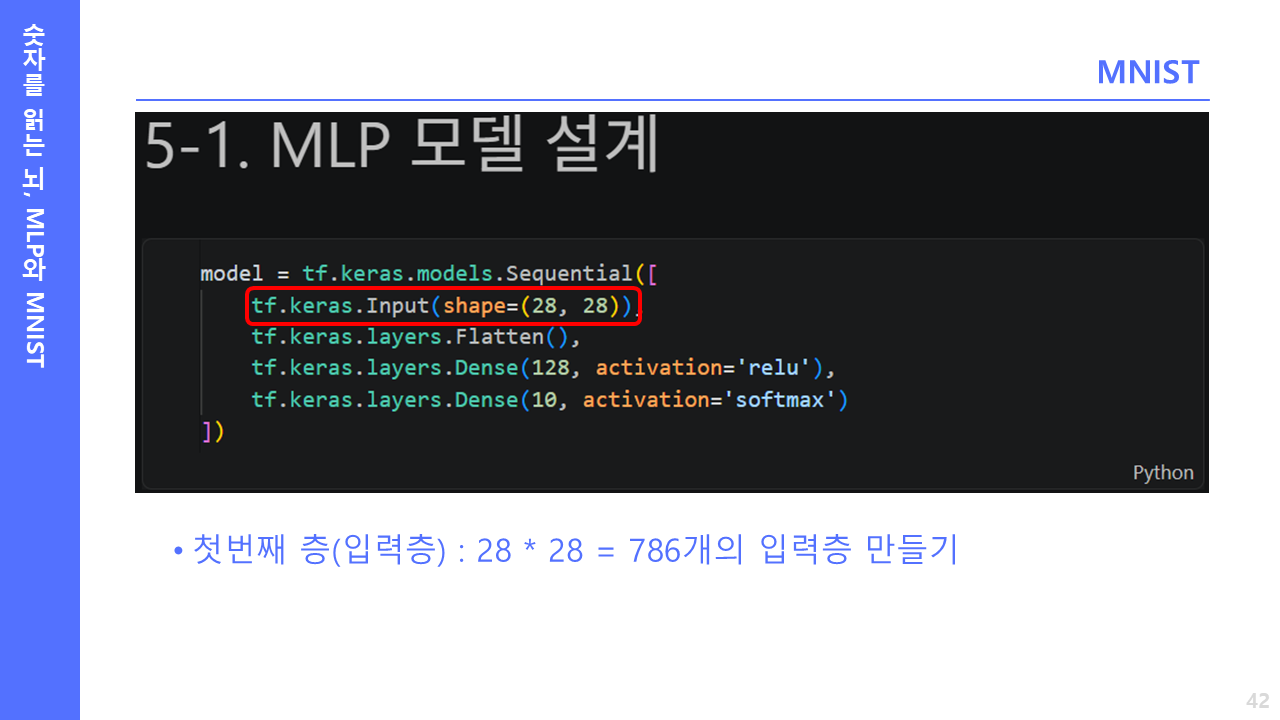

- `Input(shape=(28, 28))`: 입력의 모양을 설정. "28 * 28 짜리 이미지가 들어올 거야"라고 미리 알려주는 것

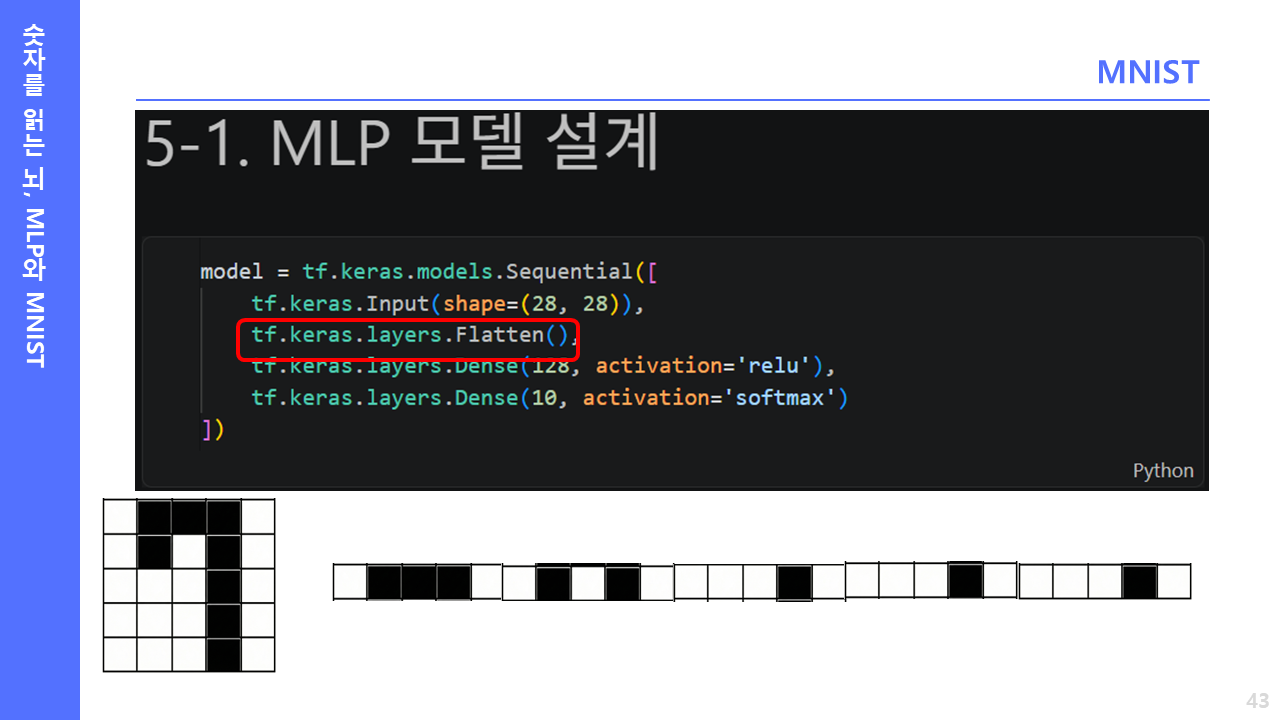

- `Flatten()`: 28 * 28 2차원을 784(=28 * 28) 1차원으로 펼침. MLP는 1차원 벡터만 받기 때문

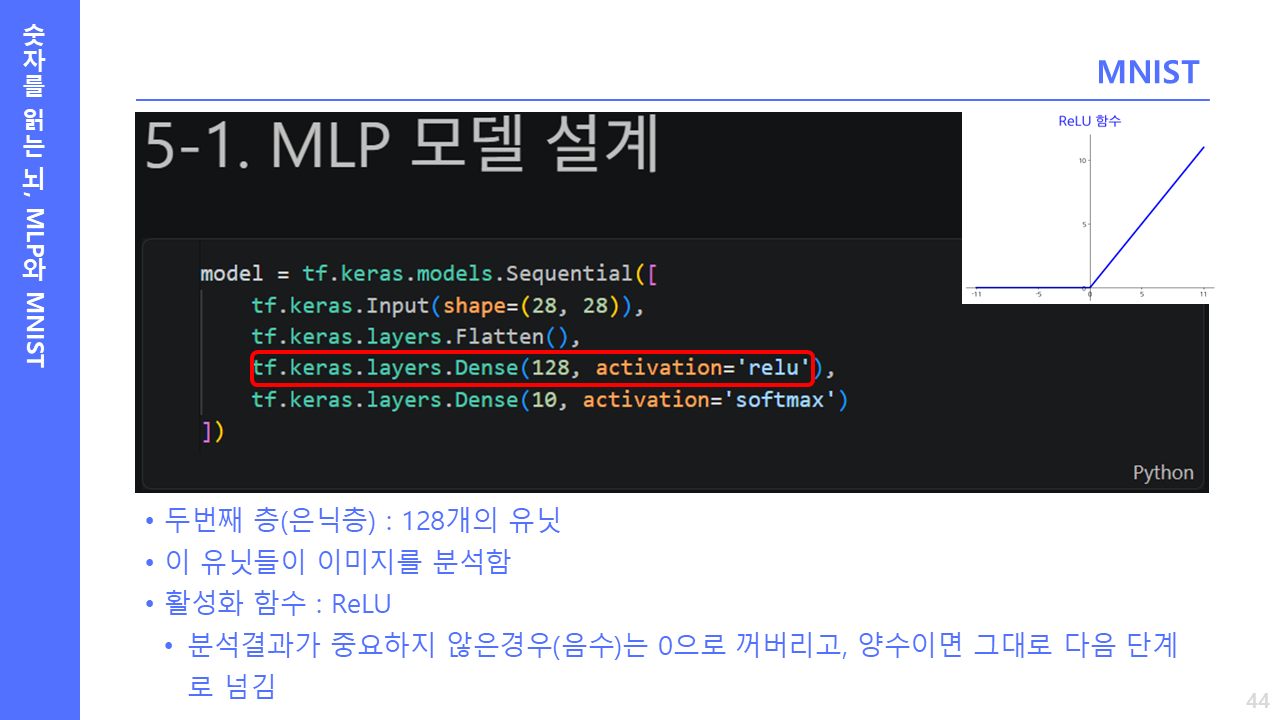

- `Dense(128, relu)`: 은닉층 128 뉴런, ReLU 활성화함수 사용. 음수면 0으로 꺼버리고, 양수면 그대로 통과

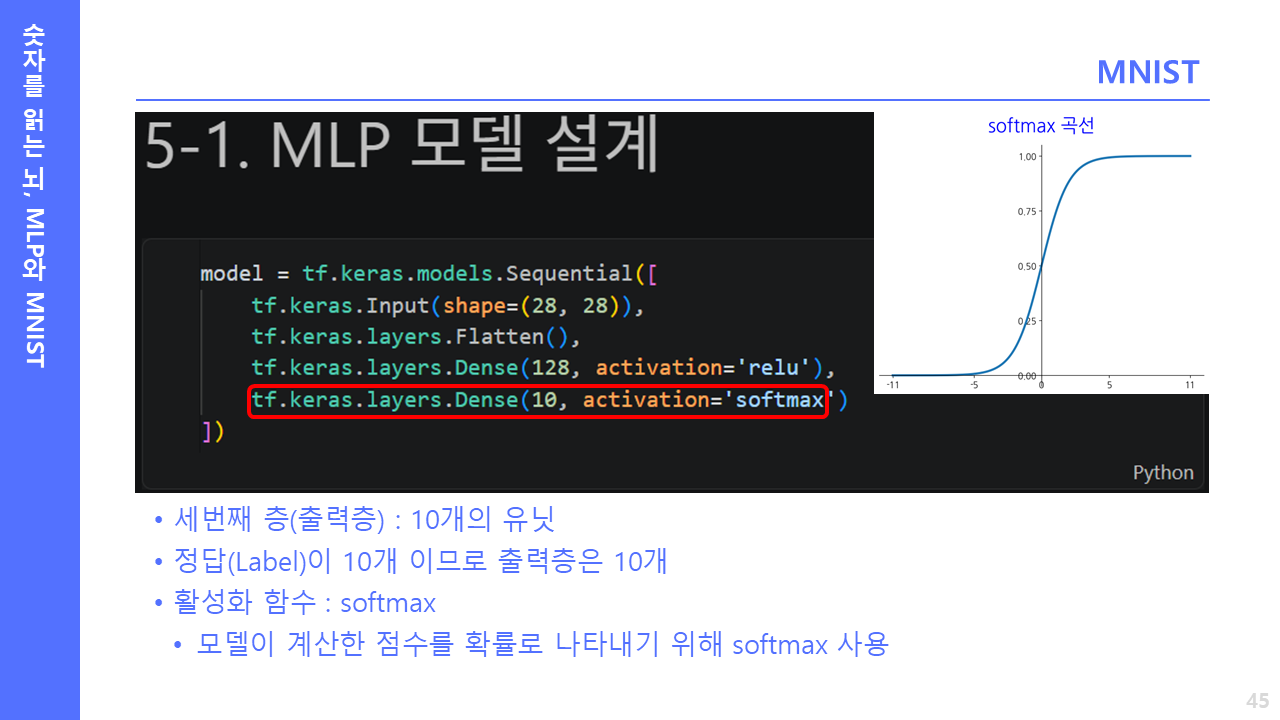

- `Dense(10, softmax): 출력층. 정답이 0 ~ 9 총 10개라서 뉴런 10개. softmax로 확률 변환

# 5-2. MLP 모델 컴파일

In [6]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

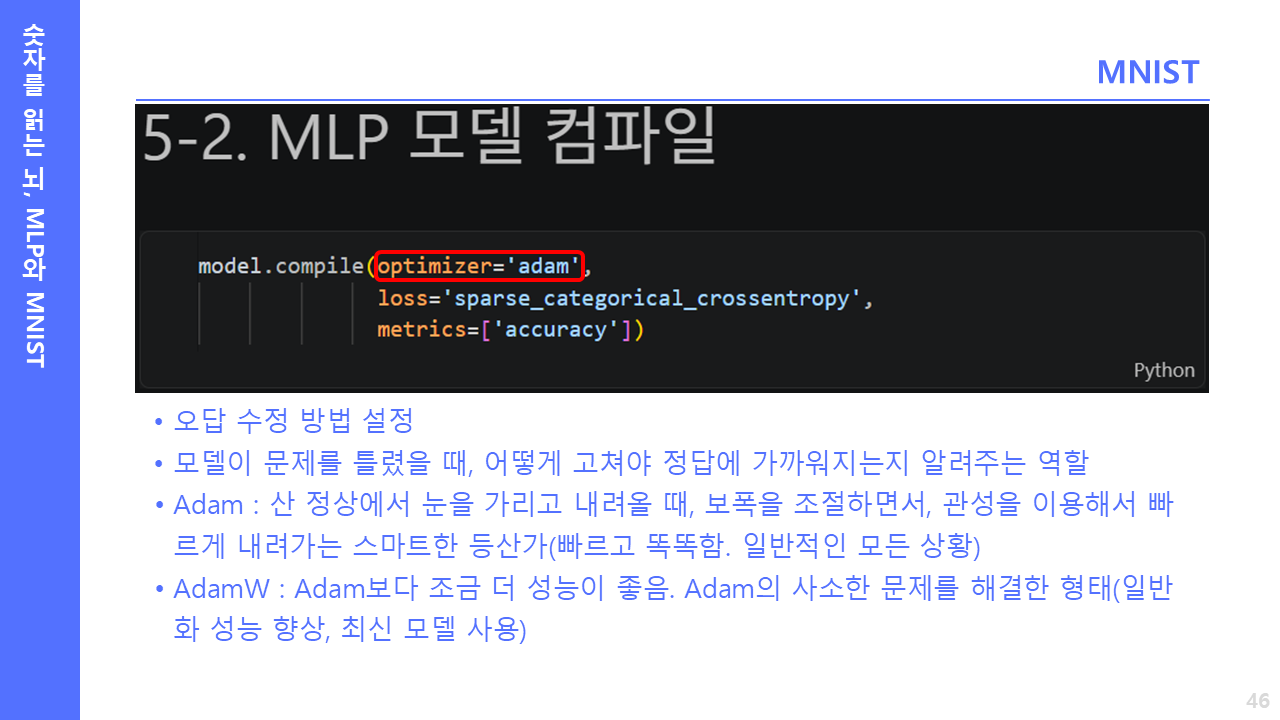

- `optimizer='adam'`: 경사하강법의 똑똑한 버전. 보폭(학습률)을 자동 조절하고 관성을 활용

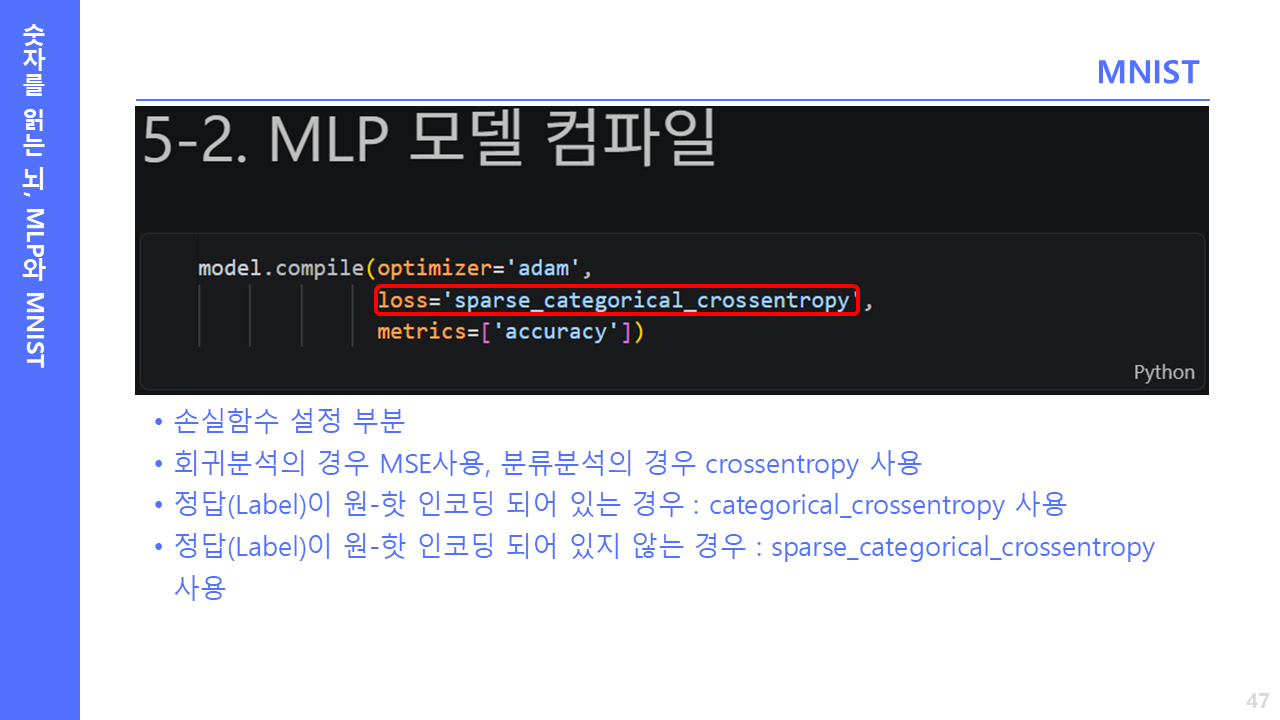

- `loss='sparse_categorical_crossentropy'`: 분류문제 + 레이블이 정수(원-핫 인코딩 되어 있지 않음)일 때 사용.

- `metrics=['accuracy']`: 학습 중 정확도 추적. loss는 자동, accuracy는 사람이 보기 직관적임.

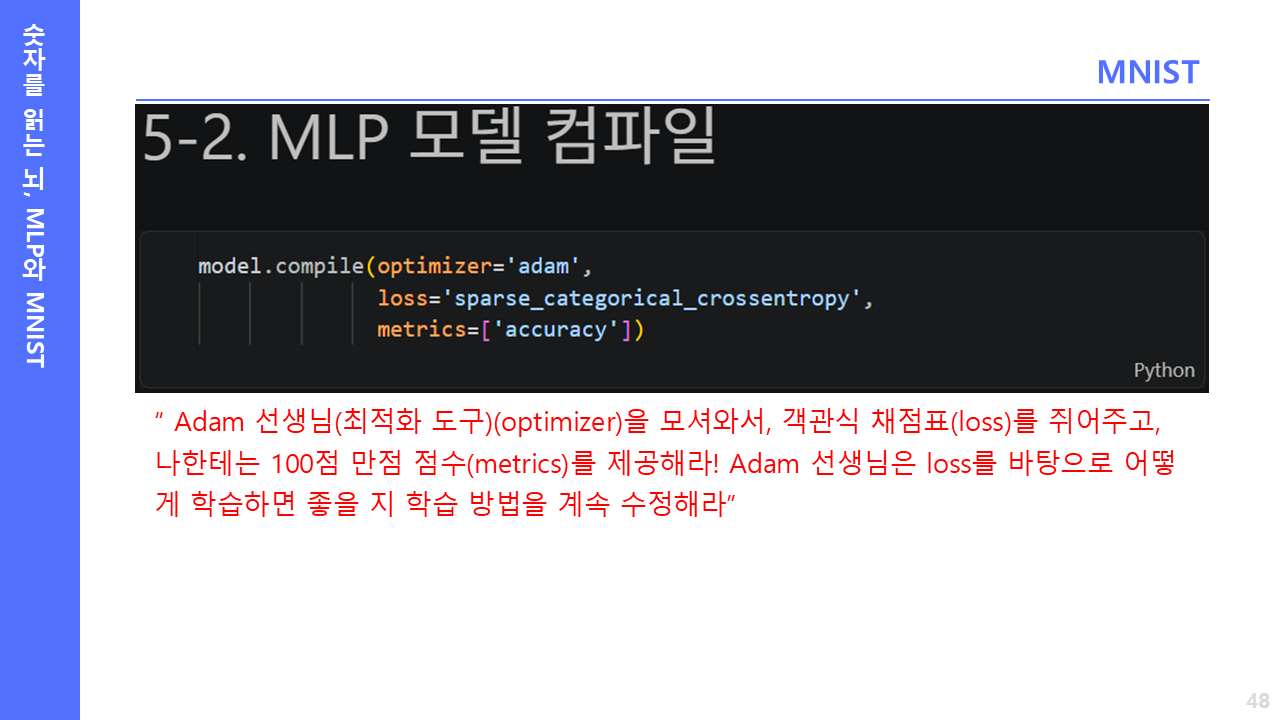

# 5-3. MLP 모델 요약

In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

- 파라미터 계산표

| 층(Layer) | 출력 모양 | 파라미터 계산 | 파라미터 수 |
|:---:|:---:|:---:|:---:|
| Input | (None, 28, 28) | - | 0 |
| Flatten | (None, 784) | 단순 모양 변환 | 0 |
| Dense(128) | (None, 128) | 784 * 128 + 128 | 100,480 |
| Dense(10) | (None, 10) | 128 * 10 + 10 | 1,290 |
| 전체 | | | 101,770 |
- 계산 원리: Dense 층의 파라미터 = (입력 뉴런 수) * (출력 뉴런 수) + (편향 = 출력 뉴런 수)
- **Dense(128)** 자세히
>- 입력은 Flatten 결과인 784개 값(28 * 28 = 784)
>>- 가중치(weight): 784개 입력이 각각 128개 뉴런에 연결 -> 784 * 128 = 100,352개
>>- 편향(bias): 각 뉴런마다 하나씩 -> 128개
>>- 합계: 100,352 + 128 = 100,480개
- **Dense(10)** 자세히
>- 입력은 앞 은닉층의 128개 값
>>- 가중치(weight): 128 * 10 = 1,280개
>>- 편향: 10개
>>- 합계: 1,280 + 10 = 1,290개
- None은 배치 크기 자리(아직 정해지지 않은 가변값). 학습 시 32나 64같은 값이 들어감

- 만약 4K 화질(3,840 * 2,160)이미지가 입력되면?
>- 입력 뉴런: 3,840 * 2,160 = 8,294,400개
>- 첫 Dense(128) 파라미터: 8,294,400 * 128 + 128 = 약 10억 6천만 개
>- 따라서 이미지 한 장을 처리하기 위해 가중치 10억 개를 학습해야 함. 컬러면 이것의 3배. 이게 다음 단원에서 CNN이 필요한 이유로 이어짐

# 6. 학습 시작

In [8]:
history = model.fit(x_train, y_train,
                    validation_split = 0.2,
                    epochs = 30)

Epoch 1/30


I0000 00:00:1786537553.848548    5259 service.cc:153] XLA service 0x7fcc24031f50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786537553.848568    5259 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.8.0)
I0000 00:00:1786537553.872237    5259 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786537554.079941    5259 cuda_dnn.cc:461] Loaded cuDNN version 90800
I0000 00:00:1786537554.093525    5259 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_919__.12
I0000 00:00:1786537554.839196    5259 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


 116/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6215 - loss: 1.2773

I0000 00:00:1786537556.330933    5259 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9187 - loss: 0.2845 - val_accuracy: 0.9567 - val_loss: 0.1553
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9631 - loss: 0.1251 - val_accuracy: 0.9654 - val_loss: 0.1171
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9754 - loss: 0.0851 - val_accuracy: 0.9695 - val_loss: 0.1046
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9820 - loss: 0.0627 - val_accuracy: 0.9717 - val_loss: 0.0994
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9871 - loss: 0.0470 - val_accuracy: 0.9728 - val_loss: 0.1000
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9908 - loss: 0.0353 - val_accuracy: 0.9727 - val_loss: 0.1009
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9935 - loss: 0.0270 - val_accuracy: 0.9749 - val_loss: 0.0984
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9953 - loss: 0.0209 - val_accurac

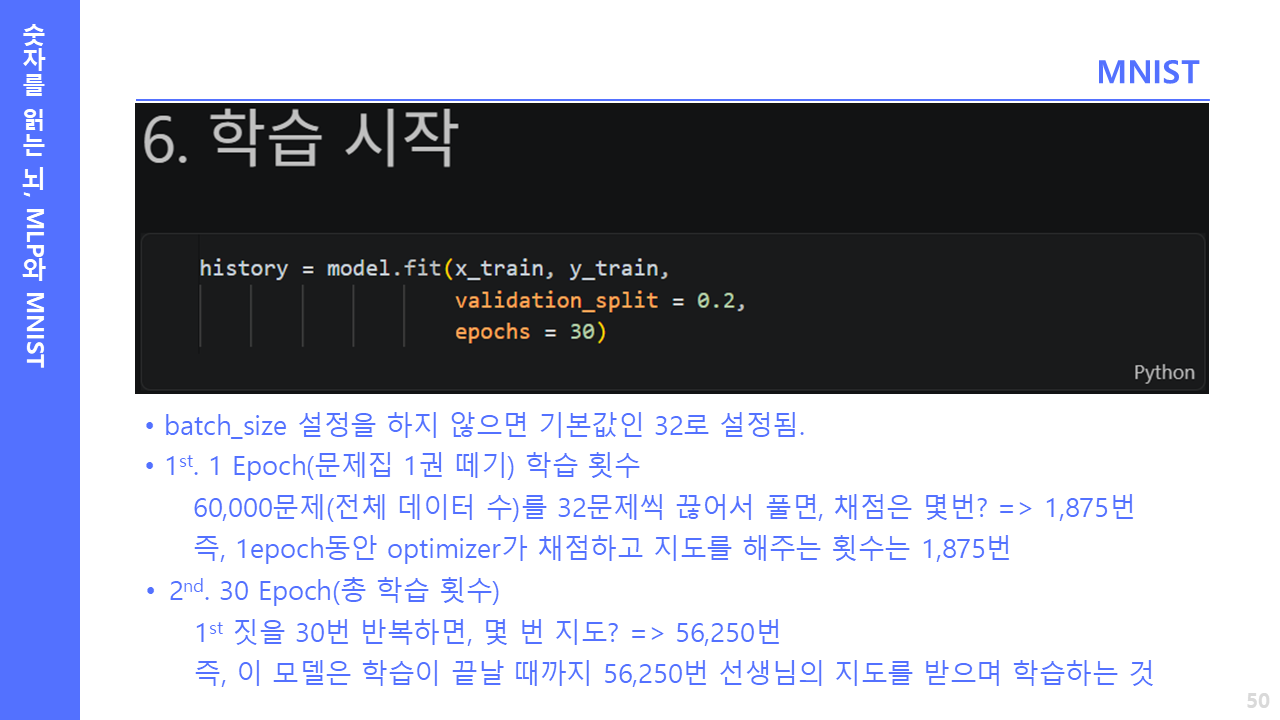

- `x_train, y_train`: 학습 데이터(이미지, 정답)
- `validation_split=0.2`: 학습 데이터의 20%를 검증용으로 사용. 즉, 60,000장 = 학습(48,000장) + 검증(12,000장)
- `epoch=30`: 30번 반복학습.
- `batch_size`: 지정하지 않았으므로 기본값 32

- 학습 횟수 계산
>- 1epoch당 채점 횟수: 48,000 / 32 = 1,500번
>- 30epoch 동안 총 가중치 업데이트: 1,500 * 30 = 45,000번
- `history`: 학습 과정의 모든 기록이 담긴 객체
>- `history.history` 안에 `'loss', 'accuracy', 'val_loss', 'val_accuracy'`가 epoch별 리스트로 저장

# 7. 최종 평가

In [9]:
print("\n========== 최종 테스트 결과 ==========")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"\n테스트 정확도: {test_acc * 100:.2f}%")


========== 최종 테스트 결과 ==========
313/313 - 2s - 7ms/step - accuracy: 0.9749 - loss: 0.1677

테스트 정확도: 97.49%


- 진짜 시험을 보는 단계
- `x_test, y_test`는 모델이 학습 중에 단 한 번도 본 적없는 1만 장의 이미지
- Validation set과 Test set의 차이:
>- Validation set: 학습 중 "잘 하고 있나?" 확인용. 하이퍼파라미터 조정에 사용 -> 간접적으로 모델이 영향받음
>- Test set: 학습이 완전히 끝난 뒤 딱 한 번 평가. 진짜 성능.

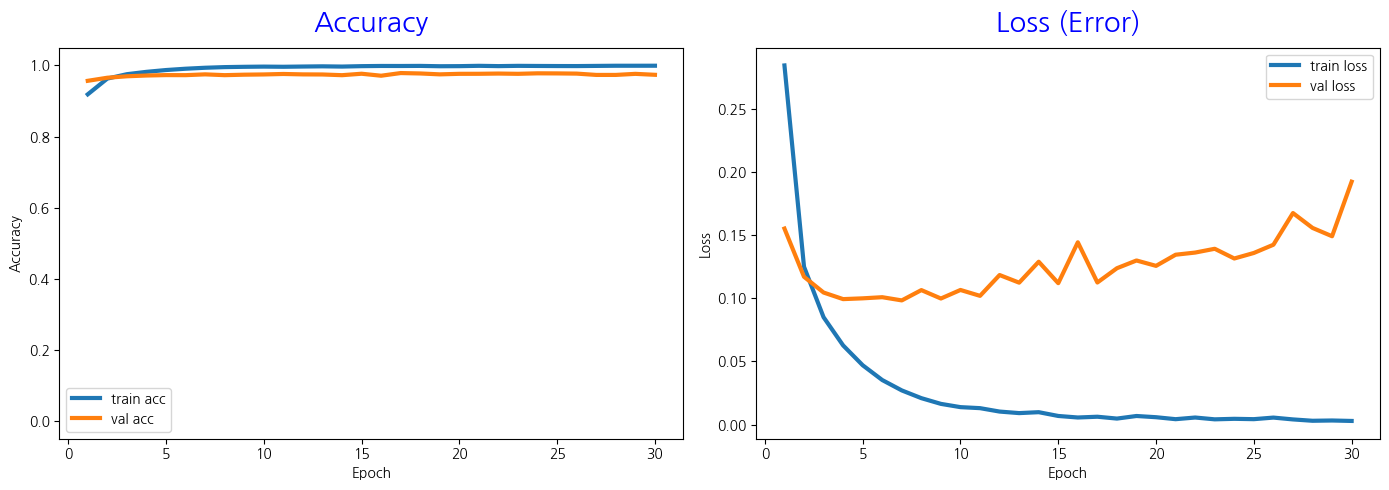

In [10]:
def plot_history_subplot(history):
    hist = history.history
    epochs = np.arange(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 가로 2개

    # =========================
    # (왼쪽) Accuracy
    # =========================
    ax = axes[0]
    ax.plot(epochs, hist["accuracy"], linewidth=3, label="train acc")
    if "val_accuracy" in hist:
        ax.plot(epochs, hist["val_accuracy"], linewidth=3, label="val acc")

    ax.set_title("Accuracy", fontsize=20, color="blue", pad=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()

    # =========================
    # (오른쪽) Loss (Error)
    # =========================
    ax = axes[1]
    ax.plot(epochs, hist["loss"], linewidth=3, label="train loss")
    if "val_loss" in hist:
        ax.plot(epochs, hist["val_loss"], linewidth=3, label="val loss")

    ax.set_title("Loss (Error)", fontsize=20, color="blue", pad=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()

    plt.tight_layout()
    plt.show()

# 학습 후 호출
plot_history_subplot(history)

- 코드 흐름
>- `history.history`에서 epoch 별 기록을 꺼냄
>- `np.arange(1, len + 1)`: x축을 1부터 30까지 만듬
>- `plt.subplots(1, 2)`: 가로로 그래프 2개 배치
>- 왼쪽엔 정확도(train vs val), 오른쪽엔 손실(train vs val)

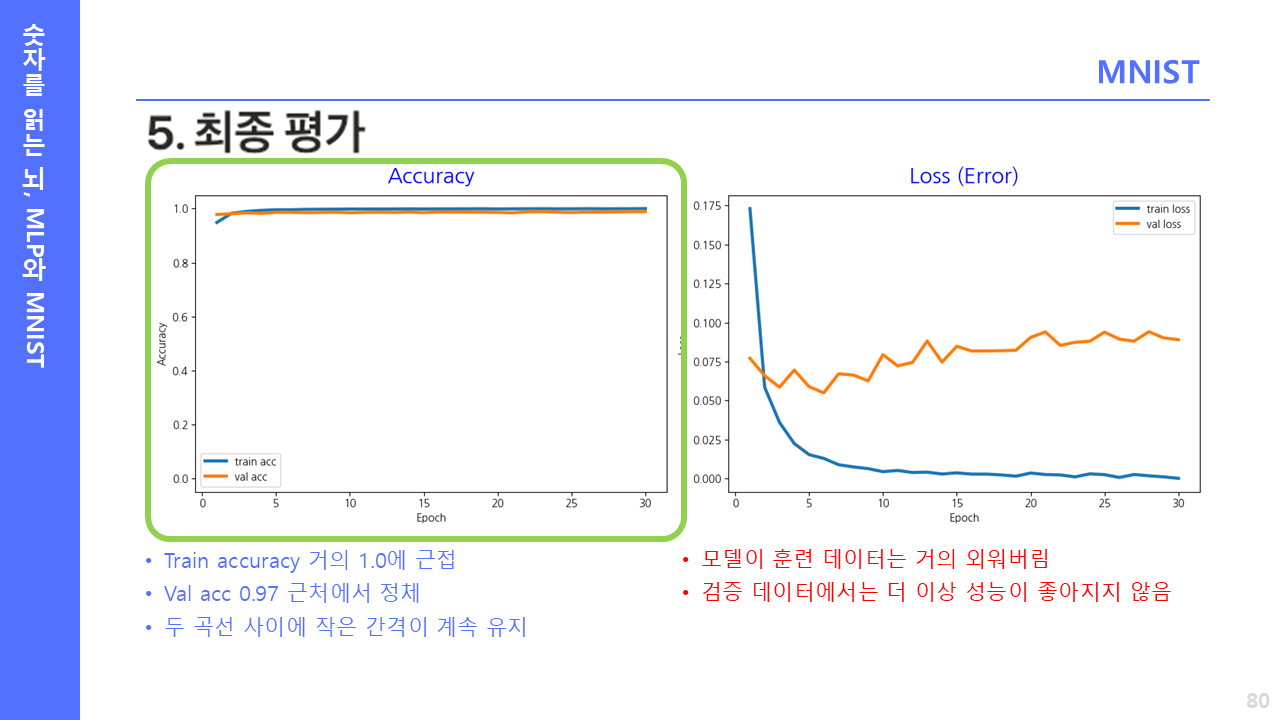

- Accuracy: Train acc는 1.0에 근접. Val acc는 0.97 근처 정체 -> 과적합 시작

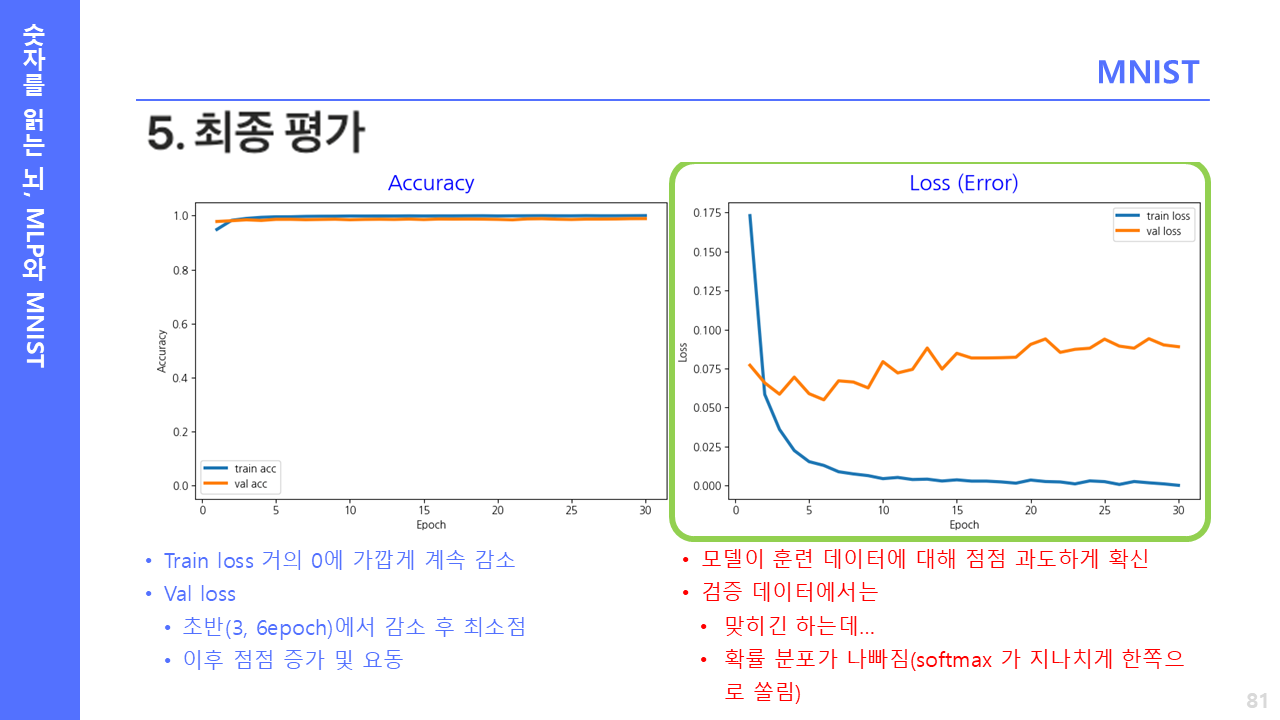

- Loss: Train loss 계속 감소. Val loss 중간에 다시 올라감 -> 모델이 훈련 데이터를 외워가는 신호

In [11]:
import pandas as pd

df = pd.DataFrame(history.history)
df.index = range(1, len(df) + 1)
df.index.name = "Epoch"
df = df.round(4)

pd.set_option('display.max_rows', None)   # 모든 행 표시
df

,accuracy,loss,val_accuracy,val_loss
Epoch,,,,
1,0.9187,0.2845,0.9567,0.1553
2,0.9631,0.1251,0.9654,0.1171
3,0.9754,0.0851,0.9695,0.1046
4,0.9820,0.0627,0.9717,0.0994
5,0.9871,0.0470,0.9728,0.1000
6,0.9908,0.0353,0.9727,0.1009
7,0.9935,0.0270,0.9749,0.0984
8,0.9953,0.0209,0.9727,0.1065
9,0.9961,0.0164,0.9740,0.0999


In [12]:
best = df['val_loss'].idxmin()
print(f"val_loss 최저: {best} epoch (val_loss={df.loc[best,'val_loss']:.4f})")
print(f"→ 이후로 val_loss가 오르면 그때부터 과적합입니다")

val_loss 최저: 7 epoch (val_loss=0.0984)
→ 이후로 val_loss가 오르면 그때부터 과적합입니다
